<a href="https://colab.research.google.com/github/ohana0/alpaco10/blob/main/%ED%85%8D%EC%8A%A4%ED%8A%B8_%EC%A0%84%EC%B2%98%EB%A6%AC_%EB%B2%A1%ED%84%B0%ED%99%94(BoW%2C_TF_IDF).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
from math import log
from matplotlib import pyplot as plt

In [24]:
from sklearn.feature_extraction.text import CountVectorizer #BoW
from sklearn.feature_extraction.text import TfidfTransformer #TF-IDF

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

예문

In [26]:
docs = [
  'I like a red apple',
  'the color of the banana is
   yellow',
  'long and yellow sweet banana',
  'I like fruits. especially apple and banana'
]

간단하게 토큰화만

In [63]:
vocab = []
for doc in docs:
    vocab += doc.split()
vocab = list(set(vocab))
len(vocab)

16

document frequency 작업을 위한 전처리.


In [64]:
#document frequency
df_list = []
for word in vocab:
    df = 0
    for doc in docs:
        if word in doc.split():
            df += 1
    df_list.append(df)
print(vocab)
print(df_list)

['long', 'I', 'is', 'red', 'banana', 'yellow', 'apple', 'and', 'sweet', 'of', 'like', 'especially', 'color', 'fruits.', 'a', 'the']
[1, 2, 1, 1, 3, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1]


위에서 만들어놓은 파라미터 목록과 df리스트(문장에 얼마나 많이들어갔는지) 두개리스트로 tf-idf값을 계산.

In [50]:
#TF-term frequency, 단어개수
table = []
for doc in docs:
    tf_idf = []
    for word,df in zip(vocab,df_list):
        # idf??
        N = len(docs)
        idf = log(N/(1+df))
        tf_idf.append(doc.split().count(word)*idf)

    table.append(tf_idf)

print(table)


[[0.0, 0.28768207245178085, 0.0, 0.6931471805599453, 0.0, 0.0, 0.28768207245178085, 0.0, 0.0, 0.0, 0.28768207245178085, 0.0, 0.0, 0.0, -0.2231435513142097, 0.0], [0.0, 0.0, 0.6931471805599453, 0.0, 0.0, 0.28768207245178085, 0.0, 0.0, 0.0, 0.6931471805599453, 0.0, 0.0, 0.6931471805599453, 0.0, -0.0, 1.3862943611198906], [0.6931471805599453, 0.0, 0.0, 0.0, 0.0, 0.28768207245178085, 0.0, 0.28768207245178085, 0.6931471805599453, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0], [0.0, 0.28768207245178085, 0.0, 0.0, 0.0, 0.0, 0.28768207245178085, 0.28768207245178085, 0.0, 0.0, 0.28768207245178085, 0.6931471805599453, 0.0, 0.6931471805599453, -0.0, 0.0]]


round함수로 보기좋게 만든모습

In [51]:
for t in table:
    li = []
    for scalar in t:
        li.append(round(scalar,2))
    print(li)

[0.0, 0.29, 0.0, 0.69, 0.0, 0.0, 0.29, 0.0, 0.0, 0.0, 0.29, 0.0, 0.0, 0.0, -0.22, 0.0]
[0.0, 0.0, 0.69, 0.0, 0.0, 0.29, 0.0, 0.0, 0.0, 0.69, 0.0, 0.0, 0.69, 0.0, -0.0, 1.39]
[0.69, 0.0, 0.0, 0.0, 0.0, 0.29, 0.0, 0.29, 0.69, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0]
[0.0, 0.29, 0.0, 0.0, 0.0, 0.0, 0.29, 0.29, 0.0, 0.0, 0.29, 0.69, 0.0, 0.69, -0.0, 0.0]


이럴필요 없고 사실 그냥 라이브러리쓰면됨 ㅋㅋ

In [31]:
cnt_vectorizer = CountVectorizer()
cnt_vectorizer.fit_transform(docs).toarray() #BoW
cnt_vectorizer.vocabulary_

{'like': 7,
 'red': 10,
 'apple': 1,
 'the': 12,
 'color': 3,
 'of': 9,
 'banana': 2,
 'is': 6,
 'yellow': 13,
 'long': 8,
 'and': 0,
 'sweet': 11,
 'fruits': 5,
 'especially': 4}

tfidf도 뚝딱

In [32]:
tfidf_transformer = TfidfTransformer()
tf_idf = tfidf_transformer.fit_transform(cnt_vectorizer.fit_transform(docs)).toarray() #TF-IDF

cosine similarity

In [33]:
#유클리드, 코사인, 자카드, 피어슨
#"유사도"  = '척도', metric
#cosine
from sklearn.metrics.pairwise import cosine_similarity

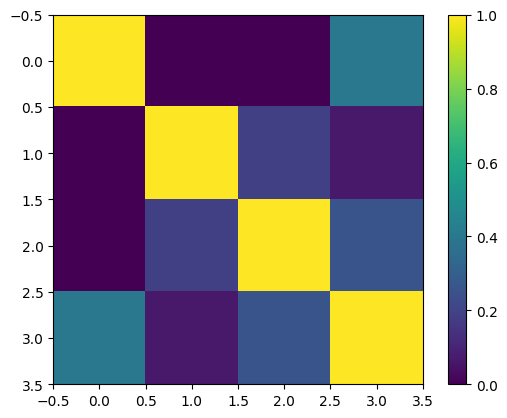

In [34]:
cosine_similarity(tf_idf,tf_idf)
plt.imshow(cosine_similarity(tf_idf,tf_idf)) # image, 히트맵
plt.colorbar()
plt.show()

index가 1인 문장이랑 제일비슷한문장 찾고싶음(자기자신말고)

In [43]:
#정렬하되, 알고싶은건 값이x인 index를 알고싶음.
#최댓값을 알고 싶은게 X, index>> argmax
sim = cosine_similarity(tf_idf,tf_idf)
np.argsort(sim[1])[::-1][1:] #index가 값의 오름차순

array([2, 3, 0])

In [52]:
sim_index = np.argsort(sim[1])[::-1][1:]

비슷한순서대로 나열하면 이렇게됨

In [53]:
for i in sim_index:
    print(docs[i])

long and yellow sweet banana
I like fruits. especially apple and banana
I like a red apple


다음 예시데이터로 작업시작

In [56]:
dir= '/content/drive/MyDrive/00_DataSEt/movies_metadata.csv'
df = pd.read_csv(dir,low_memory=False)[['title','overview']]
df.info() #null data 확인
df.dropna(inplace=True) #null data제거(inplace=True 확인)
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     45460 non-null  object
 1   overview  44512 non-null  object
dtypes: object(2)
memory usage: 710.5+ KB


,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...
...,...,...
45461,Subdue,Rising and falling between a man and woman.
45462,Century of Birthing,An artist struggles to finish his work while a...
45463,Betrayal,"When one of her hits goes wrong, a professiona..."
45464,Satan Triumphant,"In a small town live two brothers, one a minis..."


중복제거할것
중복이왜 있음? None으로 처리되지않은 공백값같은게 있겠지

In [57]:
df.nunique()

title       41371
overview    44303
dtype: int64

In [58]:
df.drop_duplicates(subset='overview',inplace=True)
df

,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...
...,...,...
45461,Subdue,Rising and falling between a man and woman.
45462,Century of Birthing,An artist struggles to finish his work while a...
45463,Betrayal,"When one of her hits goes wrong, a professiona..."
45464,Satan Triumphant,"In a small town live two brothers, one a minis..."


작업내용
라이브러리불러와서 집어넣기만하면된다.

In [59]:
#token
#품사
#불용어, 노이즈 제거
#통일화
#벡터화
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer(stop_words='english')
#내가 설정해야하는 숫자 >> 하이퍼파라미터. 여기선 max_feature
#max_feature암만줄여봐야 44000 X 44000 matrix 가 나와야되니깐 안돌아감...
#stop_words ='english' 는 stop_words사전 'english' 가져온거임그냥
tfidf = tfidf_vec.fit_transform(df['overview'])
tfidf

<44303x75827 sparse matrix of type '<class 'numpy.float64'>'
	with 1209243 stored elements in Compressed Sparse Row format>

<44506x75827 sparse matrix of type '<class 'numpy.float64'>'
	with 1210839 stored elements in Compressed Sparse Row format>
75827개 파라미터 있다는뜻임.ㅋㅋ

In [60]:
from sklearn.metrics.pairwise import cosine_similarity
# sim = cosine_similarity(tfidf,tfidf)#터짐
sim = cosine_similarity(tfidf[0].toarray(),tfidf) # 여기서 한개만골라서 하면 돌아가겠네
sim

array([[1.        , 0.01501279, 0.        , ..., 0.        , 0.00592988,
        0.        ]])

In [61]:
np.argsort(sim[0])[::-1][1:]

array([15254,  2974, 10255, ..., 28150, 28149, 22151])

*   어쩌다보니 contents-based 영화추천시스템(유사도를 사용) 만들어졋네?
*   colaborative filtering(비지도, 차원축소) 방법도있음 수업때할것.

In [62]:
df.iloc[np.argsort(sim[0])[::-1][0:10]]

,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
15348,Toy Story 3,"Woody, Buzz, and the rest of Andy's toys haven..."
2997,Toy Story 2,"Andy heads off to Cowboy Camp, leaving his toy..."
10301,The 40 Year Old Virgin,Andy Stitzer has a pleasant life with a nice a...
24523,Small Fry,A fast food restaurant mini variant of Buzz fo...
23843,Andy Hardy's Blonde Trouble,Andy is going to Wainwright College as did his...
29202,Hot Splash,Matt and Woody's summer in Cocoa Beach is goin...
43427,Andy Kaufman Plays Carnegie Hall,Andy Kaufman's legendary sold-out Carnegie Hal...
38476,Superstar: The Life and Times of Andy Warhol,Documentary portrait of Andy Warhol.
42721,Andy Peters: Exclamation Mark Question Point,Exclamation Mark Question Point is the debut s...
